# QuickDraw Stroke-by-Stroke 실시간 인식 시스템

### 성능 최적화
- **데이터 분할**: Train 70% / Val 15% / Test 15%
- **Val subset**: 10,000개 사용

### 핵심 기능
1. **Top-K 예측**: 신뢰도 낮을 때 여러 후보 제시
2. **완성도 임계값 자동 계산**: 클래스별 최적 완성도 자동 설정
3. **Stroke-by-Stroke 평가**: 얼마나 빠르고 정확하게 맞추는가?


### 10개 탈것 클래스
- 하늘: airplane , helicopter , hot air balloon
- 물: sailboat , submarine , canoe
- 땅: car , bus , train , motorbike

---

In [ ]:
# ============================================================================
# 셀 1: 라이브러리 설치 및 불러오기
# ============================================================================
# 쉽게 설명: AI를 만들기 위한 도구들을 준비하는 단계예요!

import os
import json
import random
import numpy as np
from PIL import Image, ImageDraw
from collections import defaultdict
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.models as models
import torchvision.transforms as transforms

# 랜덤 시드 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# GPU 설정
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 중인 디바이스: {device}")
if device.type == 'cuda':
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
print(f" 라이브러리 로딩 완료!")

사용 중인 디바이스: cuda
   GPU: Tesla T4
 라이브러리 로딩 완료!


---

## 하이퍼파라미터


---

In [ ]:
# ============================================================================
# 셀 2: 하이퍼파라미터 설정
# ============================================================================

# 데이터
CLASSES = [
    'hot air balloon', 'motorbike', 'sailboat', 'airplane', 'helicopter',
    'submarine', 'canoe', 'bus', 'car', 'train'
]
NUM_CLASSES = len(CLASSES)
SAMPLES_PER_CLASS = 10000

# 분할
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

# 학습
BATCH_SIZE = 128
NUM_EPOCHS = 15
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
DROPOUT_RATE = 0.3

# Top-K
TOP_K = 3

# 이미지
IMG_SIZE = 256

# 완성도 계산
COMPLETION_VAL_SAMPLES = 500

# 최적 신뢰도 계산 (삭제됨!)
# CONFIDENCE_THRESHOLDS는 나중에 Val 데이터로 클래스별 자동 계산됨

print("하이퍼파라미터 설정 완료!")
print(f"{NUM_CLASSES}개 클래스, 클래스당 {SAMPLES_PER_CLASS:,}개")
print(f" Top-{TOP_K} 예측")
print(f" 최적 신뢰도: Val 데이터로 클래스별 자동 계산")

하이퍼파라미터 설정 완료!
10개 클래스, 클래스당 10,000개
 Top-3 예측
 최적 신뢰도: Val 데이터로 클래스별 자동 계산


---

## QuickDraw 데이터셋

---

In [ ]:
# ============================================================================
# 셀 3: 데이터 다운로드
# ============================================================================

os.makedirs('quickdraw_data', exist_ok=True)
BASE_URL = "https://storage.googleapis.com/quickdraw_dataset/full/simplified"

print("QuickDraw 데이터 다운로드...")
for class_name in tqdm(CLASSES, desc="다운로드"):
    filename = f"{class_name.replace(' ', '%20')}.ndjson"
    filepath = f"quickdraw_data/{class_name.replace(' ', '_')}.ndjson"

    if os.path.exists(filepath):
        print(f"  ✓ {class_name}: 존재")
        continue

    url = f"{BASE_URL}/{filename}"
    !wget -q {url} -O {filepath}
    print(f"  ✓ {class_name}: 완료")

print("\n다운로드 완료!")

QuickDraw 데이터 다운로드...


다운로드:   0%|          | 0/10 [00:00<?, ?it/s]

  ✓ hot air balloon: 완료
  ✓ motorbike: 완료
  ✓ sailboat: 완료
  ✓ airplane: 완료
  ✓ helicopter: 완료
  ✓ submarine: 완료
  ✓ canoe: 완료
  ✓ bus: 완료
  ✓ car: 완료
  ✓ train: 완료

다운로드 완료!


---

## 획을 이미지로 변환

---

In [ ]:
# ============================================================================
# 셀 4: 전처리 함수
# ============================================================================

def convert_raw_to_simplified(raw_strokes):
    """획 데이터를 X, Y 리스트로 변환"""
    x_list = [stroke[0] for stroke in raw_strokes]
    y_list = [stroke[1] for stroke in raw_strokes]
    return x_list, y_list


def render_strokes_to_image(x_list, y_list, num_strokes_to_use=None, img_size=256):
    """획을 이미지로 렌더링"""
    img = Image.new('L', (img_size, img_size), 255)
    draw = ImageDraw.Draw(img)

    if num_strokes_to_use is None:
        num_strokes_to_use = len(x_list)

    all_x, all_y = [], []
    for i in range(num_strokes_to_use):
        all_x.extend(x_list[i])
        all_y.extend(y_list[i])

    if len(all_x) == 0:
        return img

    min_x, max_x = min(all_x), max(all_x)
    min_y, max_y = min(all_y), max(all_y)
    range_x = max(max_x - min_x, 1)
    range_y = max(max_y - min_y, 1)

    padding = 20
    scale = (img_size - 2 * padding) / max(range_x, range_y)

    for i in range(num_strokes_to_use):
        x_coords, y_coords = x_list[i], y_list[i]
        for j in range(len(x_coords) - 1):
            x1 = int((x_coords[j] - min_x) * scale + padding)
            y1 = int((y_coords[j] - min_y) * scale + padding)
            x2 = int((x_coords[j+1] - min_x) * scale + padding)
            y2 = int((y_coords[j+1] - min_y) * scale + padding)
            draw.line([(x1, y1), (x2, y2)], fill=0, width=2)

    return img


In [ ]:
# ============================================================================
# 셀 5: 데이터 로딩 및 분할
# ============================================================================

def load_and_split_data():
    all_data = []

    print("데이터 로딩...")
    for label_idx, class_name in enumerate(tqdm(CLASSES, desc="로딩")):
        filepath = f"quickdraw_data/{class_name.replace(' ', '_')}.ndjson"

        class_samples = []
        with open(filepath, 'r') as f:
            for line in f:
                sample = json.loads(line)
                if sample.get('recognized', False):
                    class_samples.append({
                        'strokes': sample['drawing'],
                        'label': label_idx,
                        'class_name': class_name
                    })
                if len(class_samples) >= SAMPLES_PER_CLASS:
                    break

        all_data.extend(class_samples)
        print(f"  ✓ {class_name}: {len(class_samples):,}개")

    random.shuffle(all_data)

    total = len(all_data)
    train_end = int(total * TRAIN_RATIO)
    val_end = train_end + int(total * VAL_RATIO)

    train_data = all_data[:train_end]
    val_data = all_data[train_end:val_end]
    test_data = all_data[val_end:]

    print(f"\n분할 완료!")
    print(f"  Train: {len(train_data):,}")
    print(f"  Val: {len(val_data):,}")
    print(f"  Test: {len(test_data):,}")

    return train_data, val_data, test_data


train_data, val_data, test_data = load_and_split_data()

데이터 로딩...


로딩:   0%|          | 0/10 [00:00<?, ?it/s]

  ✓ hot air balloon: 10,000개
  ✓ motorbike: 10,000개
  ✓ sailboat: 10,000개
  ✓ airplane: 10,000개
  ✓ helicopter: 10,000개
  ✓ submarine: 10,000개
  ✓ canoe: 10,000개
  ✓ bus: 10,000개
  ✓ car: 10,000개
  ✓ train: 10,000개

분할 완료!
  Train: 70,000
  Val: 15,000
  Test: 15,000


In [ ]:
# ============================================================================
# 셀 6: Dataset 및 DataLoader
# ============================================================================

class QuickDrawDataset(Dataset):
    def __init__(self, data, transform=None, use_partial_strokes=False):
        self.data = data
        self.transform = transform
        self.use_partial_strokes = use_partial_strokes

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        sample = self.data[idx]
        raw_strokes = sample['strokes']
        label = sample['label']

        x_strokes, y_strokes = convert_raw_to_simplified(raw_strokes)

        if self.use_partial_strokes and len(x_strokes) > 0:
            ratio = random.uniform(0.5, 1.0)
            num_strokes = max(1, int(len(x_strokes) * ratio))
        else:
            num_strokes = None

        img = render_strokes_to_image(x_strokes, y_strokes, num_strokes, IMG_SIZE)
        img = img.convert('RGB')

        if self.transform:
            img = self.transform(img)

        return img, label


train_transform = transforms.Compose([
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.15)),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = QuickDrawDataset(train_data, train_transform, use_partial_strokes=True)
val_dataset = QuickDrawDataset(val_data, eval_transform)
test_dataset = QuickDrawDataset(test_data, eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print("DataLoader 완료!")
print(f"배치: {BATCH_SIZE}")
print(f"Train 배치 수: {len(train_loader):,}")

DataLoader 완료!
배치: 128
Train 배치 수: 547


---

## MobileNetV2 모델

---


In [ ]:
# ============================================================================
# 셀 7: 모델 정의 (MobileNetV2)
# ============================================================================

class SimpleMobileNet(nn.Module):
    """MobileNetV2 기반 분류 모델 (빠르고 가벼움!)"""

    def __init__(self, num_classes, dropout_rate=0.3):
        super().__init__()

        # MobileNetV2 (ImageNet 사전학습)
        self.backbone = models.mobilenet_v2(weights='IMAGENET1K_V1')

        # 분류층 교체
        in_features = self.backbone.classifier[1].in_features
        self.backbone.classifier = nn.Sequential(
            nn.Dropout(p=dropout_rate, inplace=True),
            nn.Linear(in_features, num_classes)
        )

    def forward(self, x):
        return self.backbone(x)

    def predict_with_confidence(self, x):
        """단순 예측 + 신뢰도 (Softmax)"""
        self.eval()
        with torch.no_grad():
            output = self.forward(x)
            probs = F.softmax(output, dim=1)
            confidence, predictions = probs.max(dim=1)
        return predictions, confidence

    def predict_top_k(self, x, k=3):
        """Top-K 예측"""
        self.eval()
        with torch.no_grad():
            output = self.forward(x)
            probs = F.softmax(output, dim=1)
            top_k_probs, top_k_indices = probs.topk(k, dim=1)
        return top_k_indices, top_k_probs


model = SimpleMobileNet(num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE).to(device)

print("모델 생성 완료!")
print(f"모델: MobileNetV2 (경량화)")
print(f"클래스: {NUM_CLASSES}")
total_params = sum(p.numel() for p in model.parameters())
print(f"파라미터: {total_params:,}개")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 217MB/s]


모델 생성 완료!
모델: MobileNetV2 (경량화)
클래스: 10
파라미터: 2,236,682개


In [ ]:
# ============================================================================
# 셀 8: 학습 함수
# ============================================================================

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss, correct, total = 0, 0, 0

    pbar = tqdm(loader, desc="학습")
    for images, labels in pbar:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        pbar.set_postfix({'Loss': f'{loss.item():.4f}', 'Acc': f'{100.*correct/total:.2f}%'})

    return total_loss / len(loader), 100. * correct / total


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels in tqdm(loader, desc="평가"):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    return total_loss / len(loader), 100. * correct / total


print("학습 함수 완료!")

학습 함수 완료!


In [ ]:
# ============================================================================
# 셀 9: 학습
# ============================================================================

import os
from google.colab import drive
import json

drive.mount('/content/drive')

DRIVE_PATH = '/content/drive/MyDrive/'
os.makedirs(DRIVE_PATH, exist_ok=True)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=2)

history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
best_val_acc = 0
best_model_path = os.path.join(DRIVE_PATH, 'best_model.pth')
history_path = os.path.join(DRIVE_PATH, 'history.json')
thresholds_path = os.path.join(DRIVE_PATH, 'thresholds.json')

if os.path.exists(best_model_path):
    print(" Drive에서 저장된 모델 발견! 학습 스킵")
    model.load_state_dict(torch.load(best_model_path, map_location=device))
    model.to(device)
    print(f"{best_model_path} 로드 완료!")

    if os.path.exists(history_path):
        with open(history_path, 'r') as f:
            history = json.load(f)
        best_val_acc = max(history['val_acc']) if history['val_acc'] else 0
        print(f"최고 Val Acc: {best_val_acc:.2f}%")
else:
    print("학습 시작!")
    print("="*70)

    for epoch in range(1, NUM_EPOCHS + 1):
        print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
        print("-"*70)

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)

        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        print(f"\n결과:")
        print(f"  Train: {train_loss:.4f} | {train_acc:.2f}%")
        print(f"  Val:   {val_loss:.4f} | {val_acc:.2f}%")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), best_model_path)
            print(f" 최고 성능! ({val_acc:.2f}%) - Drive에 저장!")

        scheduler.step(val_loss)

    print("="*70)
    print(f"\n✅ 학습 완료!")
    print(f"최고 검증 정확도: {best_val_acc:.2f}%")

    with open(history_path, 'w') as f:
        json.dump(history, f, indent=2)
    print(f"학습 히스토리 저장 완료!")

    model.load_state_dict(torch.load(best_model_path))
    print(f"최고 모델 로드")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
 Drive에서 저장된 모델 발견! 학습 스킵
/content/drive/MyDrive/best_model.pth 로드 완료!
최고 Val Acc: 96.11%


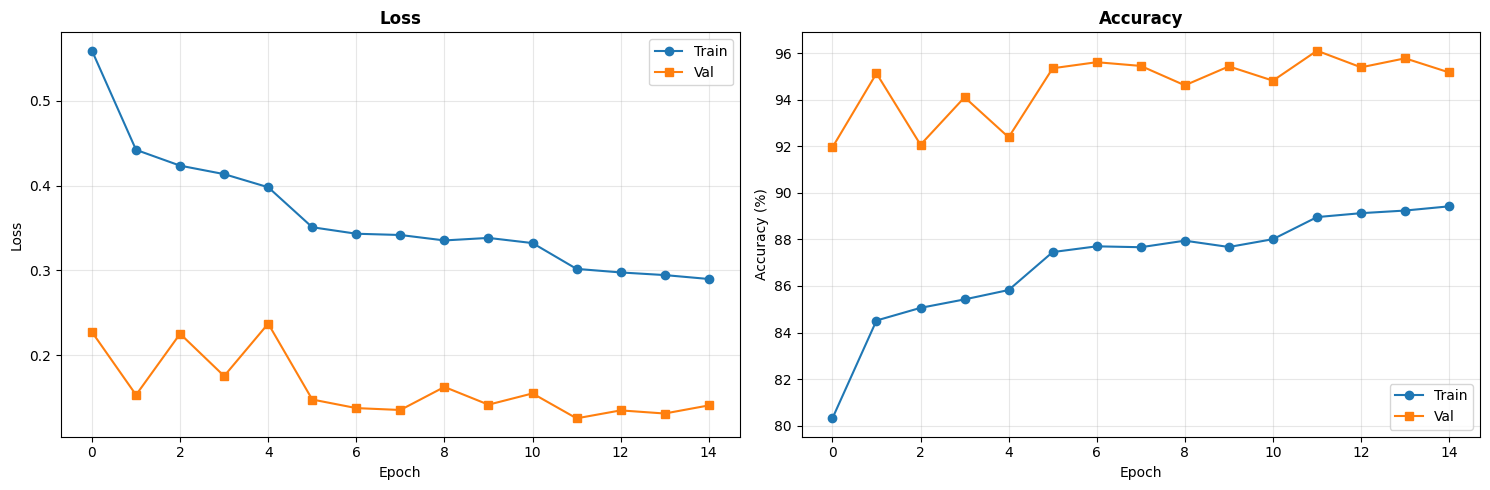


요약:
  최종 Train Acc: 89.42%
  최종 Val Acc: 95.17%
  🏆 최고 Val Acc: 96.11%


In [ ]:
# ============================================================================
# 셀 10: 학습 결과 시각화
# ============================================================================

# history가 비어있는지 확인
if history['train_acc']:  # 학습한 경우
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    axes[0].plot(history['train_loss'], label='Train', marker='o')
    axes[0].plot(history['val_loss'], label='Val', marker='s')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Loss', fontweight='bold')
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_acc'], label='Train', marker='o')
    axes[1].plot(history['val_acc'], label='Val', marker='s')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy (%)')
    axes[1].set_title('Accuracy', fontweight='bold')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"\n요약:")
    print(f"  최종 Train Acc: {history['train_acc'][-1]:.2f}%")
    print(f"  최종 Val Acc: {history['val_acc'][-1]:.2f}%")
    print(f"  🏆 최고 Val Acc: {best_val_acc:.2f}%")
else:  # 학습 스킵한 경우
    print("저장된 모델을 로드했으므로 학습 히스토리가 없습니다.")
    print("   (학습을 건너뛰었습니다)")

---

## 완성도 임계값 자동 계산


---

In [ ]:
# ============================================================================
# 셀 11: 완성도 임계값 자동 계산
# ============================================================================

def calculate_completion_thresholds_hybrid(model, train_data, val_data, device, num_val_samples=2000):
    """
    하이브리드: 통계 + Validation 미세조정
    """
    print("\n" + "="*80)
    print("완성도 임계값 자동 계산")
    print("="*80)

    # 1단계: 통계
    print("\n1단계: 통계 기반 초기 추정...")

    stroke_counts = {cls: [] for cls in CLASSES}
    for sample in tqdm(train_data, desc="획 수집"):
        cls_name = sample['class_name']
        stroke_counts[cls_name].append(len(sample['strokes']))

    avg_strokes = {cls: np.mean(counts) for cls, counts in stroke_counts.items()}

    max_strokes = max(avg_strokes.values())
    min_strokes_val = min(avg_strokes.values())

    initial_ratios = {}
    for cls_name, avg in avg_strokes.items():
        normalized = (avg - min_strokes_val) / (max_strokes - min_strokes_val)
        initial_ratios[cls_name] = 0.30 + (normalized * 0.30)

    # 2단계: Validation
    class_val_samples = {cls: [] for cls in CLASSES}
    for sample in val_data:
        cls_name = sample['class_name']
        if len(class_val_samples[cls_name]) < num_val_samples // NUM_CLASSES:
            class_val_samples[cls_name].append(sample)

    optimal_ratios = {}

    for cls_name in tqdm(CLASSES, desc="클래스별 평가"):
        samples = class_val_samples[cls_name]
        if not samples:
            optimal_ratios[cls_name] = initial_ratios[cls_name]
            continue

        success_completions = []

        for sample in samples:
            raw_strokes = sample['strokes']
            true_label = sample['label']

            x_strokes, y_strokes = convert_raw_to_simplified(raw_strokes)
            total_strokes = len(x_strokes)

            if total_strokes == 0:
                continue

            for num_strokes in range(1, total_strokes + 1):
                completion = num_strokes / total_strokes

                img = render_strokes_to_image(x_strokes, y_strokes, num_strokes, IMG_SIZE)
                img = img.convert('RGB')
                img_tensor = eval_transform(img).unsqueeze(0).to(device)

                pred, conf = model.predict_with_confidence(img_tensor)

                if pred[0].item() == true_label and conf[0].item() >= 0.90:
                    success_completions.append(completion)
                    break

        if success_completions:
            optimal_ratio = np.percentile(success_completions, 40)
            optimal_ratios[cls_name] = optimal_ratio
        else:
            optimal_ratios[cls_name] = 0.45

    print("\n완성도 임계값 계산 완료!")
    return optimal_ratios


# ── 실행부: thresholds.json 있으면 스킵 ──
if os.path.exists(thresholds_path):
    print("Drive에서 thresholds.json 발견! MIN_COMPLETION_RATIOS 계산 스킵")
    with open(thresholds_path, 'r') as f:
        _thresholds = json.load(f)
    MIN_COMPLETION_RATIOS = _thresholds['MIN_COMPLETION_RATIOS']
    print(f"MIN_COMPLETION_RATIOS 로드 완료!")
else:
    MIN_COMPLETION_RATIOS = calculate_completion_thresholds_hybrid(
        model, train_data, val_data, device, num_val_samples=2000)
    print("\n최종 MIN_COMPLETION_RATIOS:")
    for cls_name in CLASSES:
        print(f"  {cls_name:20s}: {MIN_COMPLETION_RATIOS[cls_name]:.4f}")

def calculate_min_strokes_per_class(train_data, percentile=10, safety_margin=1):

    class_strokes = {cls: [] for cls in CLASSES}

    for sample in tqdm(train_data, desc="획 수 수집"):
        cls_name = sample['class_name']
        num_strokes = len(sample['strokes'])
        class_strokes[cls_name].append(num_strokes)

    min_strokes = {}
    for cls_name, strokes in class_strokes.items():
        percentile_value = int(np.percentile(strokes, percentile))
        min_val = max(1, percentile_value - safety_margin)
        min_strokes[cls_name] = min_val

    return min_strokes


# 계산 실행 (안전 마진 1 적용)
MIN_STROKES_PER_CLASS = calculate_min_strokes_per_class(
    train_data,
    percentile=10,
    safety_margin=1
)


Drive에서 thresholds.json 발견! MIN_COMPLETION_RATIOS 계산 스킵
MIN_COMPLETION_RATIOS 로드 완료!


획 수 수집:   0%|          | 0/70000 [00:00<?, ?it/s]

In [ ]:
# ============================================================================
# 셀 12: Top-K 예측 함수
# ============================================================================

def predict_with_topk_detailed(model, image_tensor, device, k=3, class_names=None):
    """상세 Top-K 예측"""
    if class_names is None:
        class_names = CLASSES

    image_tensor = image_tensor.to(device)
    top_k_indices, top_k_probs = model.predict_top_k(image_tensor, k=k)

    top_k_indices = top_k_indices[0].cpu().numpy()
    top_k_probs = top_k_probs[0].cpu().numpy()

    results = []
    for rank, (idx, prob) in enumerate(zip(top_k_indices, top_k_probs), 1):
        results.append({
            'class_name': class_names[idx],
            'class_idx': int(idx),
            'prob': float(prob),
            'rank': rank
        })

    return results


print("Top-K 함수 완료!")

Top-K 함수 완료!


In [ ]:
# ============================================================================
# 셀 13: 최적 신뢰도 계산 (thresholds.json 있으면 스킵)
# ============================================================================

def find_optimal_confidence_per_class(model, val_data, device,
                                       min_completion_ratios, min_strokes_per_class,
                                       confidence_candidates=[0.6, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95],
                                       k=3):
    """
    각 클래스별 최적 신뢰도 임계값 자동 계산
    방법: Validation 데이터로 여러 신뢰도 시도 → 정확도 최고인 것 선택
    Returns:
        dict: {class_name: optimal_confidence}
    """
    class_confidence_results = {cls: {} for cls in CLASSES}

    for conf_threshold in tqdm(confidence_candidates, desc="신뢰도별 평가"):
        results = {cls: {'correct': 0, 'total': 0} for cls in CLASSES}

        for sample in val_data:
            raw_strokes = sample['strokes']
            true_label = sample['label']
            true_class = CLASSES[true_label]

            x_strokes, y_strokes = convert_raw_to_simplified(raw_strokes)
            total_strokes = len(x_strokes)

            if total_strokes == 0:
                continue

            results[true_class]['total'] += 1

            for num_strokes in range(1, total_strokes + 1):
                completion = num_strokes / total_strokes

                min_completion = min_completion_ratios.get(true_class, 0.35)
                if completion < min_completion:
                    continue

                img = render_strokes_to_image(x_strokes, y_strokes, num_strokes, IMG_SIZE)
                img = img.convert('RGB')
                img_tensor = eval_transform(img).unsqueeze(0).to(device)

                top_k_results = predict_with_topk_detailed(model, img_tensor, device, k=k)

                valid_results = [
                    r for r in top_k_results
                    if num_strokes >= min_strokes_per_class[r['class_name']]
                ]

                if valid_results:
                    top1_class = valid_results[0]['class_name']
                    top1_conf = valid_results[0]['prob']
                else:
                    top1_class = top_k_results[0]['class_name']
                    top1_conf = top_k_results[0]['prob']

                if top1_conf >= conf_threshold:
                    if top1_class == true_class:
                        results[true_class]['correct'] += 1
                    break

        for cls in CLASSES:
            if results[cls]['total'] > 0:
                acc = results[cls]['correct'] / results[cls]['total']
                class_confidence_results[cls][conf_threshold] = acc

    optimal_confidences = {}
    for cls in CLASSES:
        if not class_confidence_results[cls]:
            optimal_confidences[cls] = 0.80
            continue
        best_conf = max(class_confidence_results[cls].items(), key=lambda x: x[1])
        optimal_confidences[cls] = best_conf[0]

    return optimal_confidences


# 실행
if os.path.exists(thresholds_path):
    print("thresholds.json 있음 - OPTIMAL_CONFIDENCES 계산 스킵")
else:
    val_subset = random.sample(val_data, 10000)
    OPTIMAL_CONFIDENCES = find_optimal_confidence_per_class(
        model, val_subset, device,
        MIN_COMPLETION_RATIOS, MIN_STROKES_PER_CLASS,
        confidence_candidates=[0.6, 0.65, 0.70, 0.75, 0.80, 0.85, 0.90],
        k=TOP_K
    )
    print("클래스별 최적 신뢰도 계산 완료!")

thresholds.json 있음 - OPTIMAL_CONFIDENCES 계산 스킵


In [ ]:
# ============================================================================
# 셀 14: 최적 신뢰도 계산 + thresholds.json 저장
# thresholds.json이 Drive에 있으면 OPTIMAL_CONFIDENCES 계산 스킵
# ============================================================================

if os.path.exists(thresholds_path):
    print("Drive에서 thresholds.json 발견! OPTIMAL_CONFIDENCES 계산 스킵")
    OPTIMAL_CONFIDENCES = _thresholds['OPTIMAL_CONFIDENCES']
    print(f"OPTIMAL_CONFIDENCES 로드 완료!")
else:
    OPTIMAL_CONFIDENCES = find_optimal_confidence_per_class(
        model, val_data, device,
        MIN_COMPLETION_RATIOS,
        MIN_STROKES_PER_CLASS,
        k=TOP_K
    )

    thresholds = {
        "MIN_COMPLETION_RATIOS": MIN_COMPLETION_RATIOS,
        "OPTIMAL_CONFIDENCES": OPTIMAL_CONFIDENCES,
        "CLASSES": CLASSES
    }
    with open(thresholds_path, 'w') as f:
        json.dump(thresholds, f, indent=2)
    print(f"\nthresholds.json 저장 완료: {thresholds_path}")


Drive에서 thresholds.json 발견! OPTIMAL_CONFIDENCES 계산 스킵
OPTIMAL_CONFIDENCES 로드 완료!


---

## Top-K 데모

랜덤 5개 샘플로 Top-K 예측 시연!

---

 Top-K 예측 데모!



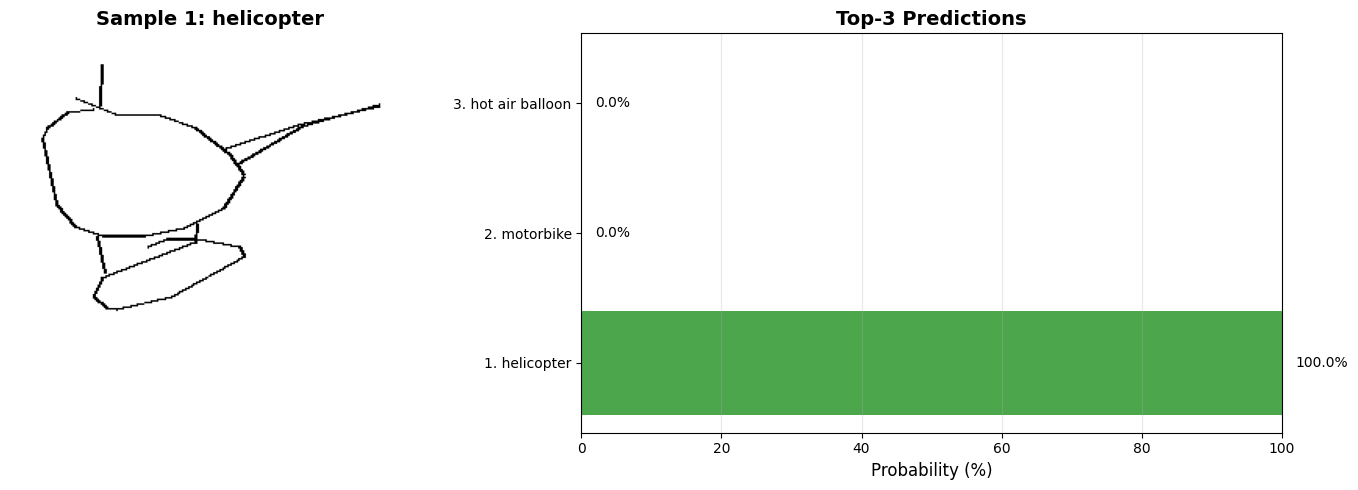


Sample 1 결과:
  정답: helicopter
  Top-1 예측: helicopter (100.0%)
  Top-1 정답!


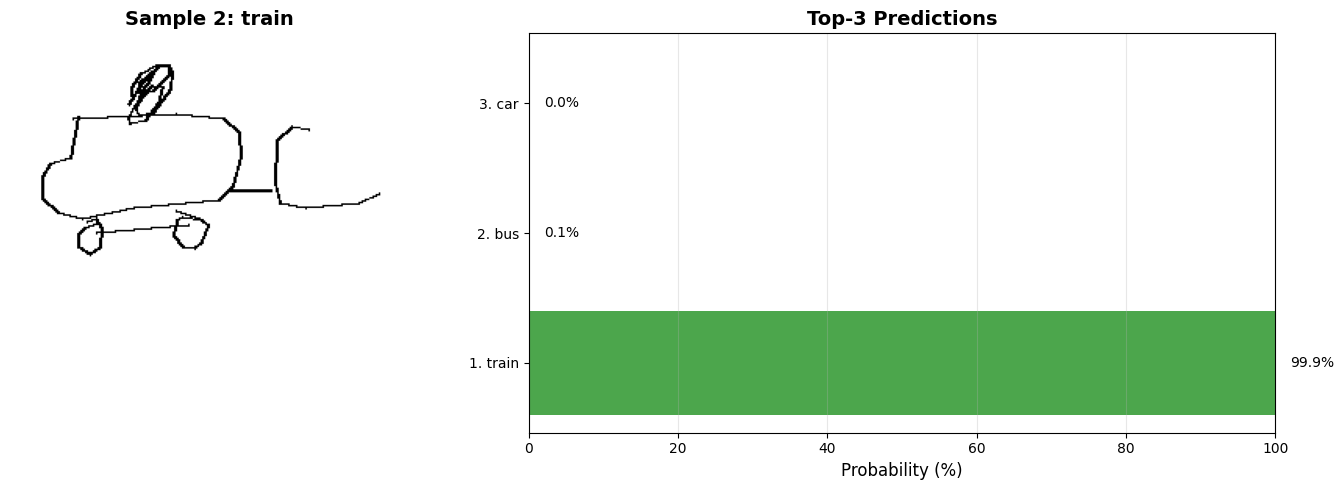


Sample 2 결과:
  정답: train
  Top-1 예측: train (99.9%)
  Top-1 정답!


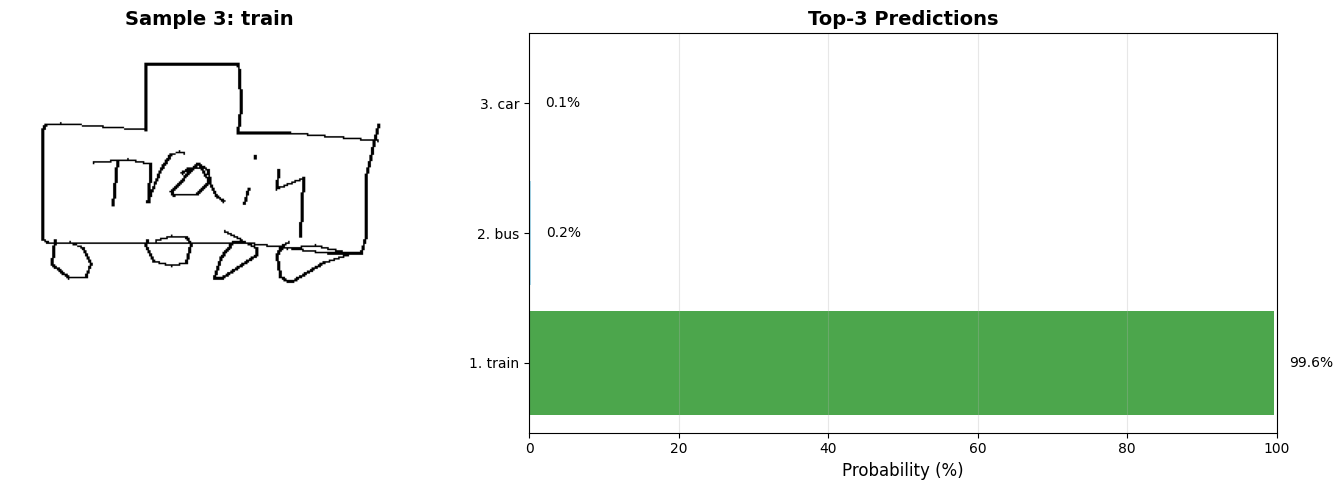


Sample 3 결과:
  정답: train
  Top-1 예측: train (99.6%)
  Top-1 정답!


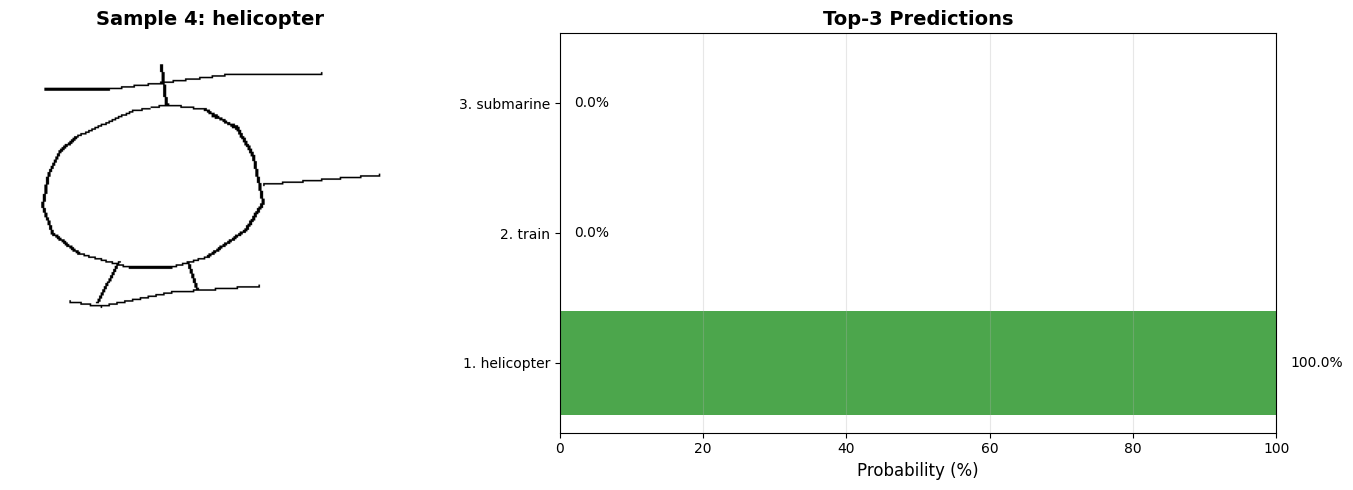


Sample 4 결과:
  정답: helicopter
  Top-1 예측: helicopter (100.0%)
  Top-1 정답!


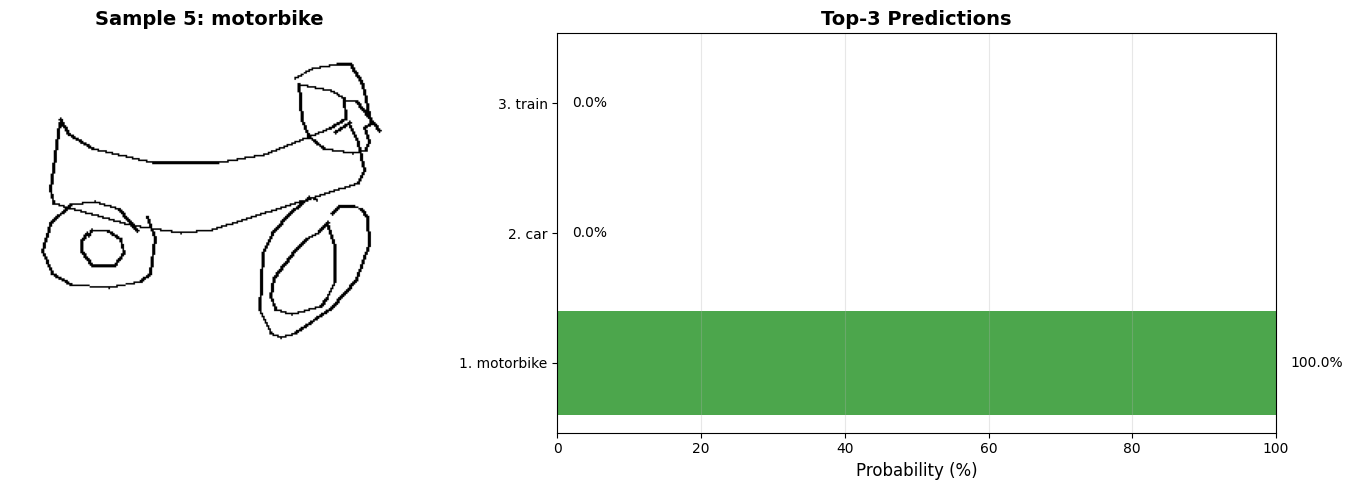


Sample 5 결과:
  정답: motorbike
  Top-1 예측: motorbike (100.0%)
  Top-1 정답!


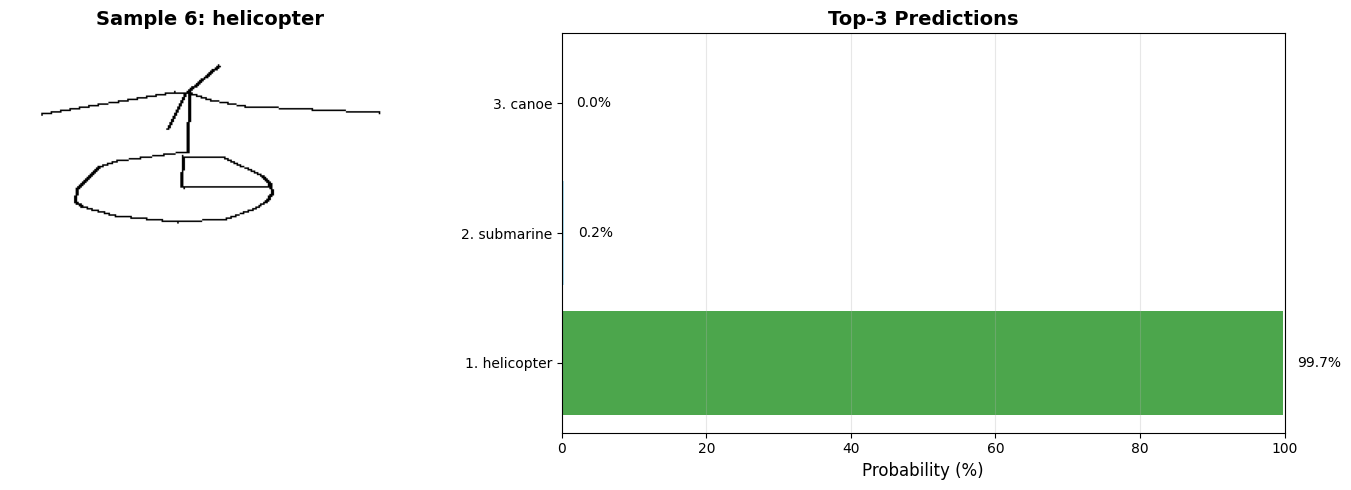


Sample 6 결과:
  정답: helicopter
  Top-1 예측: helicopter (99.7%)
  Top-1 정답!


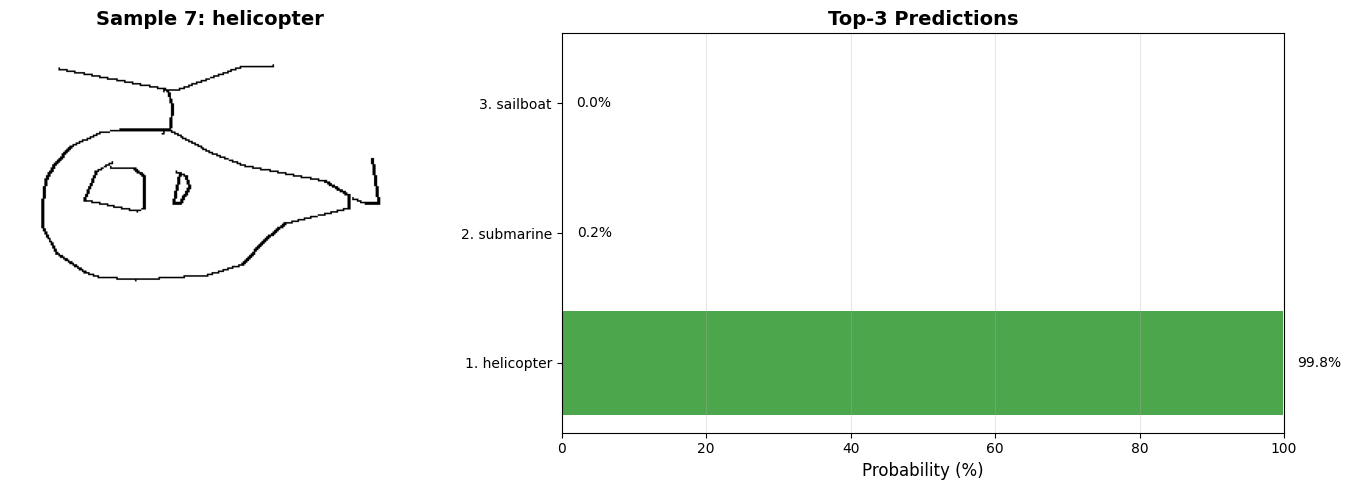


Sample 7 결과:
  정답: helicopter
  Top-1 예측: helicopter (99.8%)
  Top-1 정답!


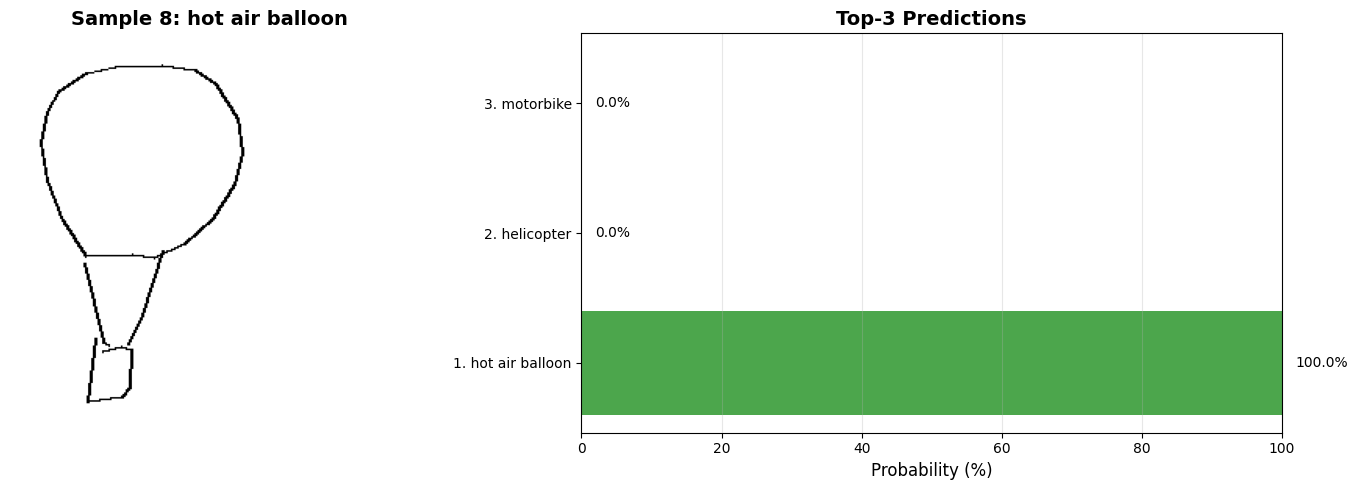


Sample 8 결과:
  정답: hot air balloon
  Top-1 예측: hot air balloon (100.0%)
  Top-1 정답!


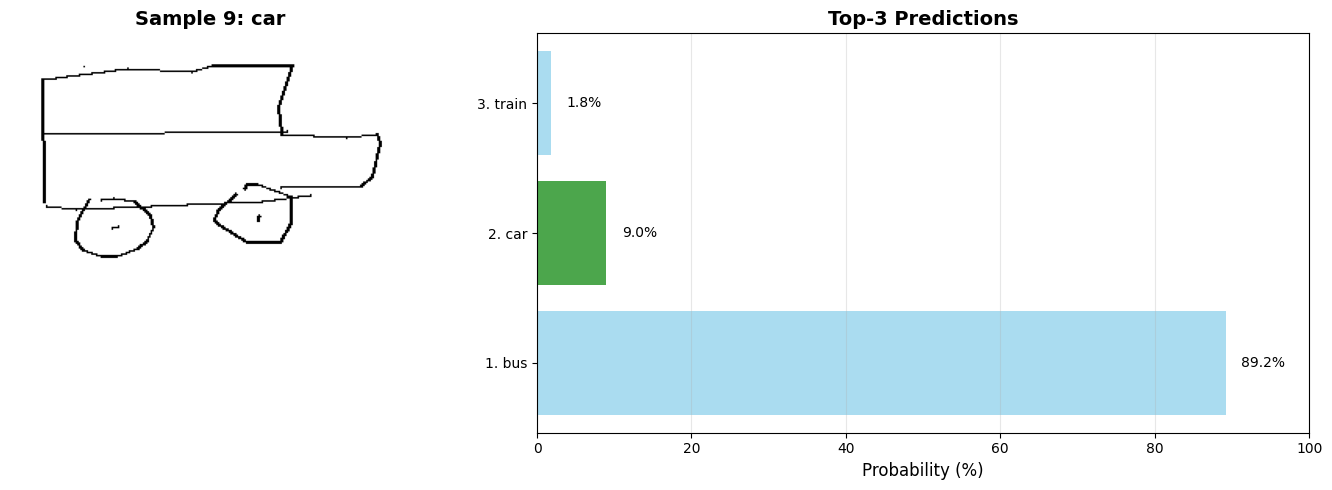


Sample 9 결과:
  정답: car
  Top-1 예측: bus (89.2%)
  Top-2에 정답 있음


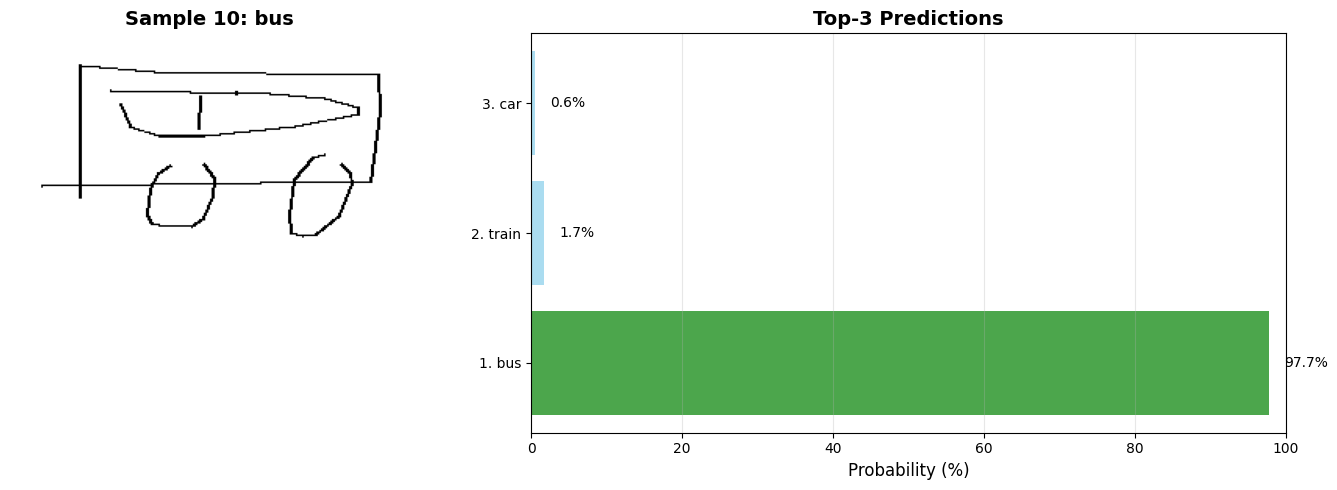


Sample 10 결과:
  정답: bus
  Top-1 예측: bus (97.7%)
  Top-1 정답!

데모 완료!


In [ ]:
# ============================================================================
# 셀 15: Top-K 데모
# ============================================================================

num_demos = 10
demo_indices = random.sample(range(len(test_data)), num_demos)

print(" Top-K 예측 데모!\n")
print("="*80)

for i, idx in enumerate(demo_indices, 1):
    sample = test_data[idx]
    raw_strokes = sample['strokes']
    true_label = sample['label']
    true_class = CLASSES[true_label]

    x_strokes, y_strokes = convert_raw_to_simplified(raw_strokes)
    img_pil = render_strokes_to_image(x_strokes, y_strokes, img_size=IMG_SIZE)
    img_pil_rgb = img_pil.convert('RGB')
    img_tensor = eval_transform(img_pil_rgb).unsqueeze(0)

    results = predict_with_topk_detailed(model, img_tensor, device, k=TOP_K)

    # 시각화
    fig = plt.figure(figsize=(14, 5))
    gs = fig.add_gridspec(1, 2, width_ratios=[1, 1.5])

    ax1 = fig.add_subplot(gs[0])
    ax1.imshow(img_pil, cmap='gray')
    ax1.set_title(f"Sample {i}: {true_class}", fontsize=14, fontweight='bold')
    ax1.axis('off')

    ax2 = fig.add_subplot(gs[1])
    class_names = [r['class_name'] for r in results]
    probs = [r['prob'] * 100 for r in results]
    colors = ['green' if cn == true_class else 'skyblue' for cn in class_names]

    bars = ax2.barh(range(len(class_names)), probs, color=colors, alpha=0.7)
    ax2.set_yticks(range(len(class_names)))
    ax2.set_yticklabels([f"{r['rank']}. {r['class_name']}" for r in results])
    ax2.set_xlabel('Probability (%)', fontsize=12)
    ax2.set_title('Top-3 Predictions', fontsize=14, fontweight='bold')
    ax2.set_xlim(0, 100)
    ax2.grid(axis='x', alpha=0.3)

    for bar, prob in zip(bars, probs):
        ax2.text(prob + 2, bar.get_y() + bar.get_height()/2, f'{prob:.1f}%',
                va='center', fontsize=10)

    plt.tight_layout()
    plt.show()

    # 결과 출력
    top1 = results[0]
    print(f"\nSample {i} 결과:")
    print(f"  정답: {true_class}")
    print(f"  Top-1 예측: {top1['class_name']} ({top1['prob']*100:.1f}%)")

    if top1['class_name'] == true_class:
        print(f"  Top-1 정답!")
    elif any(r['class_name'] == true_class for r in results):
        rank = next(r['rank'] for r in results if r['class_name'] == true_class)
        print(f"  Top-{rank}에 정답 있음")
    else:
        print(f"  Top-{TOP_K} 안에 없음")

    print("="*80)

print("\n데모 완료!")

---

## Stroke-by-Stroke 평가

### 평가 방법
1. 획을 하나씩 추가하며 예측
2. **완성도 임계값** 체크
3. **신뢰도 임계값** 도달 시 중단

---

In [ ]:
# ============================================================================
# 셀 16: Stroke-by-Stroke 평가 함수 정의 (클래스별 최적 신뢰도)
# ============================================================================

def evaluate_stroke_by_stroke_with_optimal_confidence(
    model, test_data, device, min_completion_ratios, min_strokes_per_class,
    optimal_confidences, k=3):
    """
    클래스별 최적 신뢰도를 사용한 Stroke-by-Stroke 평가
    """
    results = {cls: {'correct': 0, 'total': 0, 'stroke_counts': [], 'pixel_counts': [], 'answer_in_topk': 0}
               for cls in CLASSES}

    for sample in tqdm(test_data, desc="평가 중"):
        raw_strokes = sample['strokes']
        true_label = sample['label']
        true_class = CLASSES[true_label]

        x_strokes, y_strokes = convert_raw_to_simplified(raw_strokes)
        total_strokes = len(x_strokes)

        if total_strokes == 0:
            continue

        results[true_class]['total'] += 1
        predicted = False

        for num_strokes in range(1, total_strokes + 1):
            completion = num_strokes / total_strokes
            min_completion = min_completion_ratios.get(true_class, 0.35)

            if completion < min_completion:
                continue

            img = render_strokes_to_image(x_strokes, y_strokes, num_strokes, IMG_SIZE)
            img = img.convert('RGB')

            # 픽셀 카운트: 예측 시점의 검은 픽셀 수 측정 (grayscale 기준 128 미만)
            img_gray = img.convert('L')
            pixel_count = sum(1 for p in img_gray.getdata() if p < 128)

            img_tensor = eval_transform(img).unsqueeze(0).to(device)
            top_k_results = predict_with_topk_detailed(model, img_tensor, device, k=k)

            # 최소 획수 필터링
            valid_results = [
                r for r in top_k_results
                if num_strokes >= min_strokes_per_class[r['class_name']]
            ]

            if valid_results:
                top1_class = valid_results[0]['class_name']
                top1_conf = valid_results[0]['prob']
            else:
                continue

            threshold = optimal_confidences[top1_class]

            if top1_conf >= threshold:
                if top1_class == true_class:
                    results[true_class]['correct'] += 1
                    results[true_class]['pixel_counts'].append(pixel_count)  # 정답일 때만 기록
                results[true_class]['stroke_counts'].append(num_strokes)
                predicted = True

                topk_classes = [r['class_name'] for r in valid_results]
                if true_class in topk_classes:
                    results[true_class]['answer_in_topk'] += 1
                break

        if not predicted:
            results[true_class]['stroke_counts'].append(total_strokes)

    return results


In [ ]:
# ============================================================================
# 셀 17: 📊 클래스별 최적 신뢰도로 Stroke-by-Stroke 평가
# ============================================================================

print("🎯 클래스별 최적 신뢰도로 Stroke-by-Stroke 평가!\n")

results = evaluate_stroke_by_stroke_with_optimal_confidence(
    model, test_data, device,
    MIN_COMPLETION_RATIOS,
    MIN_STROKES_PER_CLASS,
    OPTIMAL_CONFIDENCES,
    k=TOP_K
)

all_results = results

total_correct = sum(r['correct'] for r in results.values())
total_samples = sum(r['total'] for r in results.values())
overall_acc = 100 * total_correct / total_samples if total_samples > 0 else 0

print(f"\n{'='*60}")
print(f"📊 전체 요약")
print(f"{'='*60}")
print(f"  평균 정확도: {overall_acc:.2f}%")
print(f"{'='*60}")

print(f"\n클래스별 정확도:")
print(f"{'='*60}")
for cls_name in CLASSES:
    r = results[cls_name]
    acc = 100 * r['correct'] / r['total'] if r['total'] > 0 else 0
    print(f"  {cls_name:20s}: {acc:.1f}%")
print(f"{'='*60}")

print("\n✅ 평가 완료!")


🎯 클래스별 최적 신뢰도로 Stroke-by-Stroke 평가!



평가 중:   0%|          | 0/15000 [00:00<?, ?it/s]


📊 전체 요약
  평균 정확도: 91.29%

클래스별 정확도:
  hot air balloon     : 96.4%
  motorbike           : 96.0%
  sailboat            : 92.4%
  airplane            : 95.5%
  helicopter          : 90.9%
  submarine           : 93.8%
  canoe               : 86.1%
  bus                 : 92.4%
  car                 : 86.6%
  train               : 83.0%

✅ 평가 완료!


---

## 결과 테이블


---

In [ ]:
# ============================================================================
# 셀 18: 최종 결과 요약
# ============================================================================

print("\n" + "="*60)
print(" "*15 + "최종 성능 요약")
print("="*60)

print(f"{'Class':<22} {'Accuracy':>10}")
print("="*60)

for cls_name in CLASSES:
    r = all_results[cls_name]
    acc = 100 * r['correct'] / r['total'] if r['total'] > 0 else 0
    print(f"{cls_name:<22} {acc:>9.1f}%")

print("-"*60)

total_correct = sum(all_results[c]['correct'] for c in CLASSES)
total_samples = sum(all_results[c]['total'] for c in CLASSES)
overall_acc = 100 * total_correct / total_samples if total_samples > 0 else 0

print(f"{'OVERALL':<22} {overall_acc:>9.2f}%")
print("="*60)



               최종 성능 요약
Class                    Accuracy
hot air balloon             96.4%
motorbike                   96.0%
sailboat                    92.4%
airplane                    95.5%
helicopter                  90.9%
submarine                   93.8%
canoe                       86.1%
bus                         92.4%
car                         86.6%
train                       83.0%
------------------------------------------------------------
OVERALL                    91.29%
